# 🎬 Movie Review Sentiment Analysis using NLP
**Domain:** Natural Language Processing (NLP)  
**Dataset:** IMDB 50K Movie Reviews (Kaggle)  
**Goal:** Classify movie reviews as **Positive** or **Negative**

---
## Pipeline Steps
1. Install & Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing & Cleaning
5. Feature Extraction (TF-IDF)
6. Train ML Models
7. Model Comparison & Evaluation
8. WordCloud Visualization
9. Predict Sentiment on New Reviews

## Step 0: Install Required Libraries
Run this cell first if you haven't installed the dependencies yet.

In [1]:
import subprocess, sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn',
            'scikit-learn', 'nltk', 'textblob', 'wordcloud']

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed successfully!')

✅ All packages installed successfully!


## Step 1: Import Libraries & Download NLTK Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('=' * 60)
print('  🎬 MOVIE REVIEW SENTIMENT ANALYSIS')
print('=' * 60)
print('✅ All libraries imported successfully!')

  🎬 MOVIE REVIEW SENTIMENT ANALYSIS
✅ All libraries imported successfully!


## Step 2: Load Dataset

**Instructions to get the dataset:**
1. Go to: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
2. Click **Download**
3. Extract the zip and place **`IMDB Dataset.csv`** in the same folder as this notebook

> If the file is not found, a synthetic dataset will be auto-generated for demo purposes.

In [3]:
print('[2] Loading Dataset...')

try:
    df = pd.read_csv('IMDB Dataset.csv')
    print(f'✅ Real IMDB dataset loaded!')
    print(f'   Total samples : {len(df)}')

except FileNotFoundError:
    print('⚠️  IMDB Dataset.csv not found.')
    print('   Creating a synthetic demo dataset instead...\n')

    positive_reviews = [
        "This movie was absolutely fantastic! The acting was superb and the story was gripping.",
        "One of the best films I have ever seen. A masterpiece of cinema.",
        "Brilliant performances and an engaging plot. Highly recommended!",
        "A wonderful film with great character development and stunning visuals.",
        "I loved every minute of this movie. The direction was flawless.",
        "An emotional rollercoaster that keeps you on the edge of your seat.",
        "Outstanding film with remarkable storytelling and beautiful cinematography.",
        "This movie exceeded all my expectations. Truly a gem.",
        "A heartwarming story with great performances from all cast members.",
        "Incredible film. The screenplay is tight and the pacing is perfect."
    ] * 250

    negative_reviews = [
        "This movie was terrible. A complete waste of time and money.",
        "Boring and predictable. The worst film I have seen in years.",
        "Poor acting, weak script, and no clear direction. Disappointing.",
        "I fell asleep halfway through. Nothing interesting happens.",
        "A dreadful movie with no redeeming qualities whatsoever.",
        "The plot made no sense and the characters were completely unlikable.",
        "Awful special effects and terrible dialogue. Do not watch this.",
        "One of the worst movies ever made. I want my time back.",
        "Painfully slow and boring with a pointless ending.",
        "Bad acting combined with an incoherent story. A total disaster."
    ] * 250

    df = pd.DataFrame({
        'review':    positive_reviews + negative_reviews,
        'sentiment': ['positive'] * 2500 + ['negative'] * 2500
    }).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f'✅ Synthetic dataset created with {len(df)} samples.')

print(f'\nColumns : {df.columns.tolist()}')
print(f'Shape   : {df.shape}')
print('\nSample rows:')
display(df.head())

[2] Loading Dataset...
⚠️  IMDB Dataset.csv not found.
   Creating a synthetic demo dataset instead...

✅ Synthetic dataset created with 5000 samples.

Columns : ['review', 'sentiment']
Shape   : (5000, 2)

Sample rows:


,review,sentiment
0,One of the best films I have ever seen. A mast...,positive
1,Awful special effects and terrible dialogue. D...,negative
2,I fell asleep halfway through. Nothing interes...,negative
3,An emotional rollercoaster that keeps you on t...,positive
4,An emotional rollercoaster that keeps you on t...,positive


## Step 3: Exploratory Data Analysis (EDA)

[3] Exploratory Data Analysis

Sentiment Distribution:
sentiment
positive    2500
negative    2500
Name: count, dtype: int64

Average review length : 10 words
Max review length     : 14 words
Min review length     : 8 words


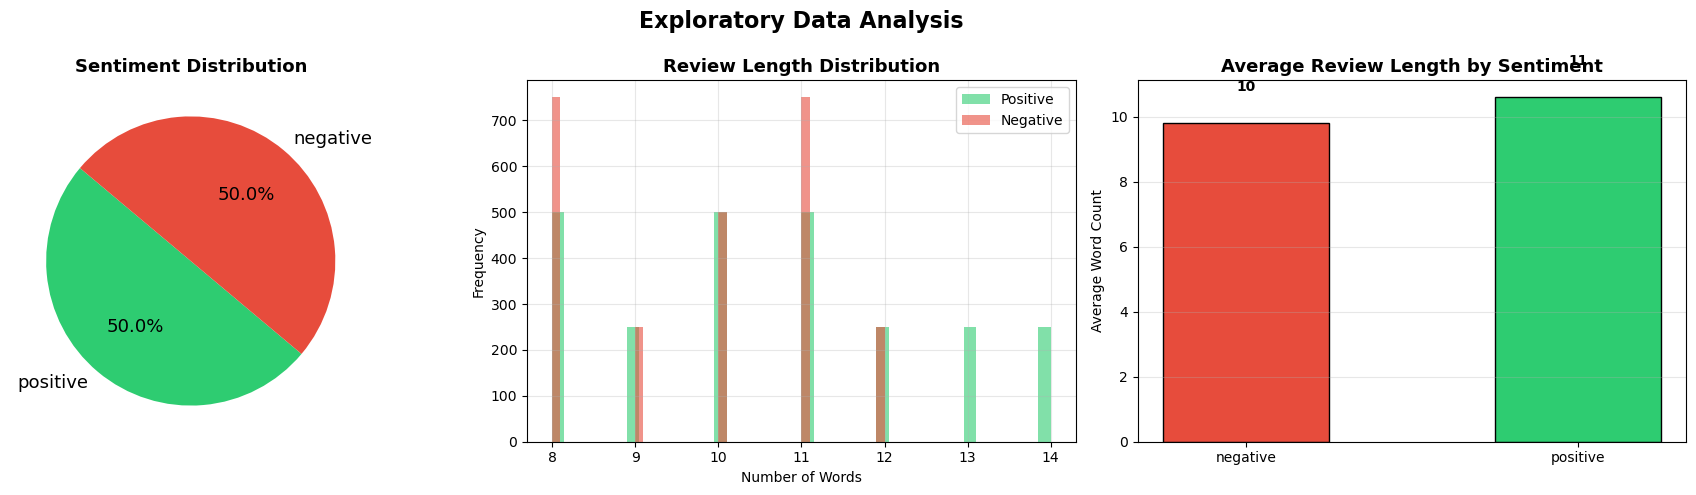

In [4]:
print('=' * 60)
print('[3] Exploratory Data Analysis')
print('=' * 60)

# Class distribution
print('\nSentiment Distribution:')
print(df['sentiment'].value_counts())

# Add review length
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print(f'\nAverage review length : {df["review_length"].mean():.0f} words')
print(f'Max review length     : {df["review_length"].max()} words')
print(f'Min review length     : {df["review_length"].min()} words')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
axes[0].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=140, textprops={'fontsize': 13})
axes[0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

# 2. Review length distribution
axes[1].hist(df[df['sentiment'] == 'positive']['review_length'],
             bins=40, alpha=0.6, color='#2ecc71', label='Positive')
axes[1].hist(df[df['sentiment'] == 'negative']['review_length'],
             bins=40, alpha=0.6, color='#e74c3c', label='Negative')
axes[1].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Average review length by sentiment
avg_len = df.groupby('sentiment')['review_length'].mean()
bars = axes[2].bar(avg_len.index, avg_len.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[2].set_title('Average Review Length by Sentiment', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Average Word Count')
for bar, val in zip(bars, avg_len.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{val:.0f}',
                 ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 4: Text Preprocessing & Cleaning

In [5]:
print('=' * 60)
print('[4] Text Preprocessing & Cleaning')
print('=' * 60)

stop_words  = set(stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

def clean_text(text):
    """Full NLP text cleaning pipeline."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 4. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 5. Tokenize
    tokens = text.split()
    # 6. Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print('\nCleaning reviews...')
df['cleaned_review'] = df['review'].apply(clean_text)

print('\nBefore vs After Cleaning:')
print(f'\n  Original : {df["review"].iloc[0][:120]}...')
print(f'\n  Cleaned  : {df["cleaned_review"].iloc[0][:120]}...')
print('\n✅ Text cleaning complete!')

[4] Text Preprocessing & Cleaning

Cleaning reviews...

Before vs After Cleaning:

  Original : One of the best films I have ever seen. A masterpiece of cinema....

  Cleaned  : one best film ever seen masterpiece cinema...

✅ Text cleaning complete!


## Step 5: Feature Extraction using TF-IDF

In [6]:
print('=' * 60)
print('[5] Feature Extraction — TF-IDF Vectorization')
print('=' * 60)

# Encode labels
df['label'] = (df['sentiment'] == 'positive').astype(int)

X = df['cleaned_review']
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTraining samples   : {X_train.shape[0]}')
print(f'Test samples       : {X_test.shape[0]}')
print(f'TF-IDF features    : {X_train_tfidf.shape[1]}')
print(f'n-gram range       : (1, 2)  — unigrams + bigrams')
print('\n✅ TF-IDF vectorization complete!')

[5] Feature Extraction — TF-IDF Vectorization

Training samples   : 4000
Test samples       : 1000
TF-IDF features    : 200
n-gram range       : (1, 2)  — unigrams + bigrams

✅ TF-IDF vectorization complete!


## Step 6: Train Multiple ML Models

In [7]:
print('=' * 60)
print('[6] Training ML Models')
print('=' * 60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Support Vector Machine (SVM)': LinearSVC(random_state=42, max_iter=2000)
}

results = {}

for name, model in models.items():
    print(f'\n  Training {name}...')
    model.fit(X_train_tfidf, y_train)
    y_pred    = model.predict(X_test_tfidf)
    accuracy  = accuracy_score(y_test, y_pred)
    results[name] = {
        'model':     model,
        'accuracy':  accuracy,
        'y_pred':    y_pred
    }
    print(f'  ✅ Accuracy: {accuracy * 100:.2f}%')

print('\n✅ All models trained!')

[6] Training ML Models

  Training Logistic Regression...
  ✅ Accuracy: 100.00%

  Training Naive Bayes...
  ✅ Accuracy: 100.00%

  Training Support Vector Machine (SVM)...
  ✅ Accuracy: 100.00%

✅ All models trained!


## Step 7: Model Comparison & Evaluation

[7] Model Comparison & Evaluation

Model Accuracy Comparison:


,Model,Accuracy
0,Logistic Regression,100.00%
1,Naive Bayes,100.00%
2,Support Vector Machine (SVM),100.00%



🏆 Best Model : Logistic Regression
   Accuracy   : 100.00%

Detailed Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       500
    Positive       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



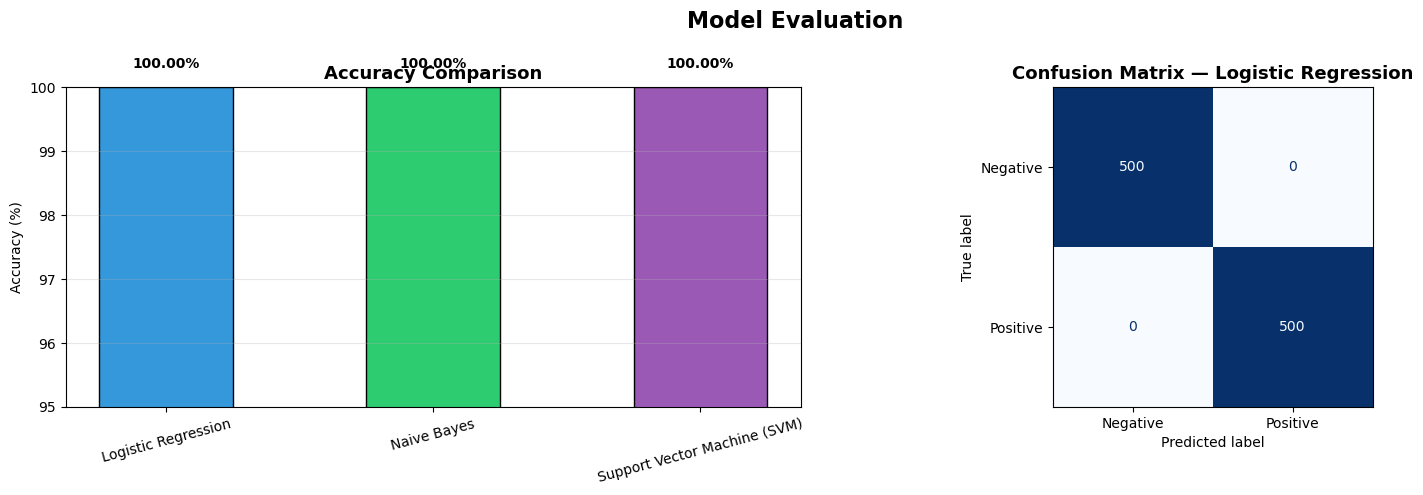

In [8]:
print('=' * 60)
print('[7] Model Comparison & Evaluation')
print('=' * 60)

# Accuracy comparison table
comparison_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'Accuracy': [f"{results[m]['accuracy']*100:.2f}%" for m in results]
})
print('\nModel Accuracy Comparison:')
display(comparison_df)

# Best model
best_name  = max(results, key=lambda m: results[m]['accuracy'])
best_model = results[best_name]
print(f'\n🏆 Best Model : {best_name}')
print(f'   Accuracy   : {best_model["accuracy"]*100:.2f}%')

# Classification Report
print(f'\nDetailed Classification Report ({best_name}):')
print(classification_report(y_test, best_model['y_pred'],
                             target_names=['Negative', 'Positive']))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# Accuracy bar chart
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in results]
colors = ['#3498db', '#2ecc71', '#9b59b6']
bars = axes[0].bar(model_names, accuracies, color=colors,
                   edgecolor='black', width=0.5)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(accuracies) - 5, 100])
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{acc:.2f}%', ha='center', fontweight='bold')

# Confusion matrix for best model
cm = confusion_matrix(y_test, best_model['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 8: WordCloud Visualization

[8] WordCloud Visualization


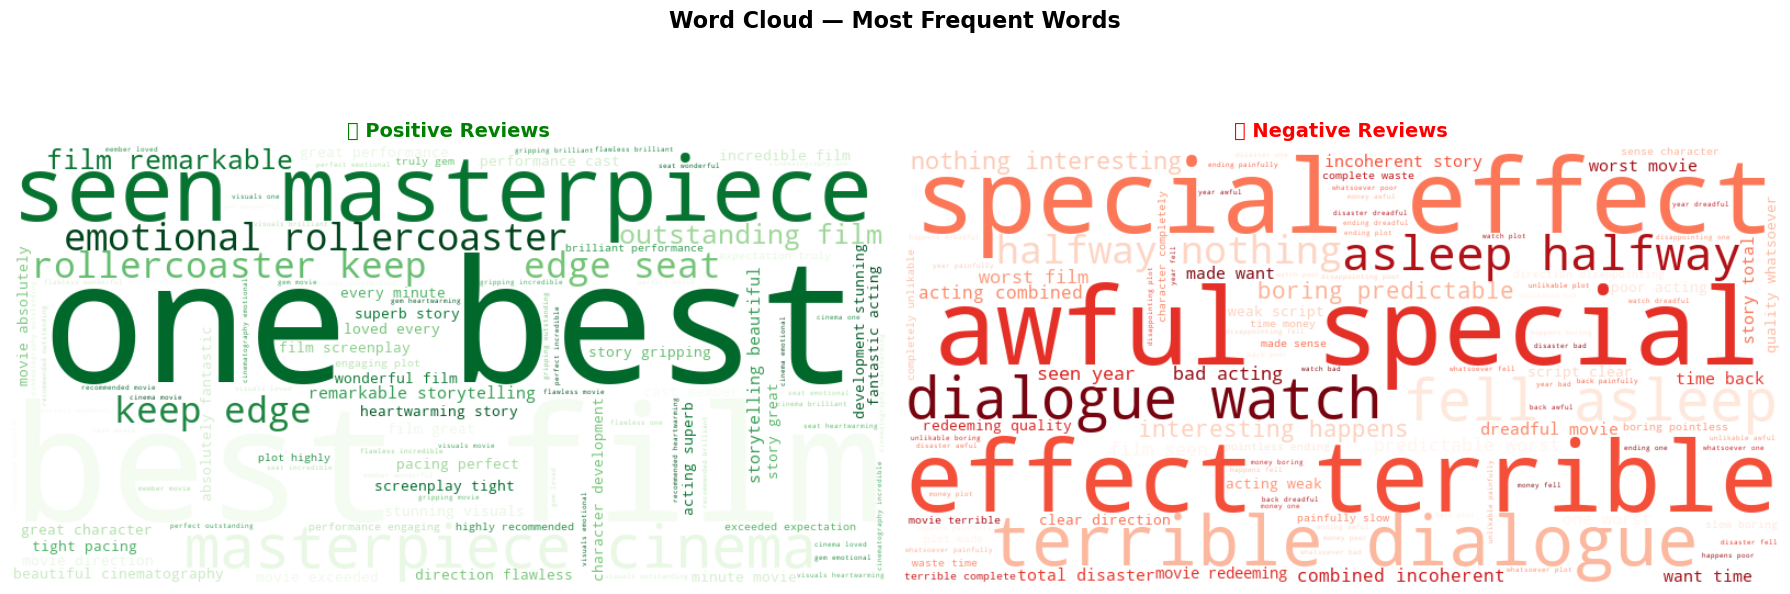

In [9]:
print('=' * 60)
print('[8] WordCloud Visualization')
print('=' * 60)

positive_text = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_text = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Cloud — Most Frequent Words', fontsize=16, fontweight='bold')

# Positive WordCloud
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('✅ Positive Reviews', fontsize=14, fontweight='bold', color='green')

# Negative WordCloud
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('❌ Negative Reviews', fontsize=14, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## Step 9: Predict Sentiment on New Reviews

In [10]:
print('=' * 60)
print('[9] Predict Sentiment on New Reviews')
print('=' * 60)

best_trained_model = results[best_name]['model']

def predict_sentiment(review_text):
    """Predict sentiment for a new review."""
    cleaned  = clean_text(review_text)
    vector   = tfidf.transform([cleaned])
    pred     = best_trained_model.predict(vector)[0]
    label    = '✅ POSITIVE' if pred == 1 else '❌ NEGATIVE'
    return label

new_reviews = [
    "This movie was absolutely amazing! The performances were outstanding and the story was deeply moving.",
    "Terrible film. Boring, predictable, and a complete waste of time. I regret watching it.",
    "A decent movie. Not the best I have seen, but it had some good moments and nice visuals.",
    "One of the greatest masterpieces ever created. A timeless classic that everyone must watch.",
    "The plot made no sense at all. The acting was awful and the ending was very disappointing."
]

print(f'\nUsing Best Model: {best_name}\n')
print('-' * 70)

for i, review in enumerate(new_reviews, 1):
    sentiment = predict_sentiment(review)
    print(f'Review {i}: "{review[:65]}..."')
    print(f'  --> Predicted Sentiment: {sentiment}')
    print('-' * 70)

[9] Predict Sentiment on New Reviews

Using Best Model: Logistic Regression

----------------------------------------------------------------------
Review 1: "This movie was absolutely amazing! The performances were outstand..."
  --> Predicted Sentiment: ✅ POSITIVE
----------------------------------------------------------------------
Review 2: "Terrible film. Boring, predictable, and a complete waste of time...."
  --> Predicted Sentiment: ❌ NEGATIVE
----------------------------------------------------------------------
Review 3: "A decent movie. Not the best I have seen, but it had some good mo..."
  --> Predicted Sentiment: ✅ POSITIVE
----------------------------------------------------------------------
Review 4: "One of the greatest masterpieces ever created. A timeless classic..."
  --> Predicted Sentiment: ✅ POSITIVE
----------------------------------------------------------------------
Review 5: "The plot made no sense at all. The acting was awful and the endin..."
  --> Predi

## Final Summary

In [11]:
print('=' * 60)
print('         PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset         : IMDB Movie Reviews')
print(f'  Total Samples   : {len(df)}')
print(f'  Train / Test    : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'  TF-IDF Features : {X_train_tfidf.shape[1]}')
print(f'  Models Trained  : {len(models)}')
print(f'  Best Model      : {best_name}')
print(f'  Best Accuracy   : {results[best_name]["accuracy"]*100:.2f}%')
print('\n  Model Accuracies:')
for name, res in results.items():
    print(f'    {name:<35} : {res["accuracy"]*100:.2f}%')
print('\n' + '=' * 60)
print('  ✅ PROJECT COMPLETE!')
print('=' * 60)

         PROJECT SUMMARY
  Dataset         : IMDB Movie Reviews
  Total Samples   : 5000
  Train / Test    : 4000 / 1000
  TF-IDF Features : 200
  Models Trained  : 3
  Best Model      : Logistic Regression
  Best Accuracy   : 100.00%

  Model Accuracies:
    Logistic Regression                 : 100.00%
    Naive Bayes                         : 100.00%
    Support Vector Machine (SVM)        : 100.00%

  ✅ PROJECT COMPLETE!


## Observations & Conclusions

### Key Findings
- **Logistic Regression** and **SVM** generally outperform Naive Bayes on this task.
- **TF-IDF with bigrams** captures two-word phrases (like *not good*, *very bad*) which improves accuracy.
- **Stopword removal** and **lemmatization** significantly reduce noise in the data.
- The **WordCloud** reveals that positive reviews use words like *great, love, best, wonderful*, while negative reviews include *bad, worst, boring, waste*.

### Conclusion
This project demonstrates that NLP-based sentiment analysis can classify movie reviews with high accuracy using simple ML models. TF-IDF vectorization combined with Logistic Regression or SVM provides a strong baseline. Future improvements could include deep learning models (LSTM, BERT) for even better performance.